# Import Library and Dataset

In [ ]:
# pip install emoji


In [1]:
# Import essential library
import pandas as pd
import numpy as np
import re, html, emoji
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

In [2]:
# Import datasets
general_df = pd.read_csv("goemotions_mrm8488_train.csv")
domain_df = pd.read_csv("stockemotions_full.csv", skiprows = 1)

print(general_df.shape)
print(domain_df.shape)
print(general_df.head(10))
print(domain_df.head(10))

(211225, 37)
(10000, 7)
                                                text       id  \
0                                    That game hurt.  eew5j0j   
1   >sexuality shouldn’t be a grouping category I...  eemcysk   
2     You do right, if you don't care then fuck 'em!  ed2mah1   
3                                 Man I love reddit.  eeibobj   
4  [NAME] was nowhere near them, he was by the Fa...  eda6yn6   
5  Right? Considering it’s such an important docu...  eespn2i   
6  He isn't as big, but he's still quite popular....  eczuekb   
7  That's crazy; I went to a super [RELIGION] hig...  ed5tx8y   
8                                that's adorable asf  ef961hv   
9  "Sponge Blurb Pubs Quaw Haha GURR ha AAa!" fin...  edl7cr3   

                author             subreddit    link_id   parent_id  \
0                Brdd9                   nrl  t3_ajis4z  t1_eew18eq   
1          TheGreen888      unpopularopinion  t3_ai4q37   t3_ai4q37   
2             Labalool           confessions  t

# Basic Statistics


In [3]:
# The shape of the datasets
print(f'General Dataset: {general_df.shape}')
print(f'Domain Dataset: {domain_df.shape}')

General Dataset: (211225, 37)
Domain Dataset: (10000, 7)


In [4]:
# Check datatype
print(general_df.info())
print("________________________________\n")
print(domain_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 211225 entries, 0 to 211224
Data columns (total 37 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   text                  211225 non-null  str    
 1   id                    211225 non-null  str    
 2   author                211225 non-null  str    
 3   subreddit             211225 non-null  str    
 4   link_id               211225 non-null  str    
 5   parent_id             211225 non-null  str    
 6   created_utc           211225 non-null  float64
 7   rater_id              211225 non-null  int64  
 8   example_very_unclear  211225 non-null  bool   
 9   admiration            211225 non-null  int64  
 10  amusement             211225 non-null  int64  
 11  anger                 211225 non-null  int64  
 12  annoyance             211225 non-null  int64  
 13  approval              211225 non-null  int64  
 14  caring                211225 non-null  int64  
 15  confusion  

In [5]:
# Checking missing value
print(f'General Dataset: {general_df.isnull().sum()}')
print("________________________________\n")
print(f'Domain Dataset: {domain_df.isnull().sum()}')

General Dataset: text                    0
id                      0
author                  0
subreddit               0
link_id                 0
parent_id               0
created_utc             0
rater_id                0
example_very_unclear    0
admiration              0
amusement               0
anger                   0
annoyance               0
approval                0
caring                  0
confusion               0
curiosity               0
desire                  0
disappointment          0
disapproval             0
disgust                 0
embarrassment           0
excitement              0
fear                    0
gratitude               0
grief                   0
joy                     0
love                    0
nervousness             0
optimism                0
pride                   0
realization             0
relief                  0
remorse                 0
sadness                 0
surprise                0
neutral                 0
dtype: int64
________

# Clean Dataset



In [6]:

# Fiter ()"example_very_unclear" = True) as it do not have any label
general_df = general_df[~general_df["example_very_unclear"]]
print(general_df["example_very_unclear"].head(10))

0     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
Name: example_very_unclear, dtype: bool


In [7]:
# Applying rarest-label strategy to balance the dataset
min_vote = 2
emotion_cols = general_df.columns[9:].tolist()
agg = general_df.groupby('text')[emotion_cols].sum()
mask = agg >= min_vote
agg = agg[mask.any(axis = 1)]
mask = mask[mask.any(axis = 1)]
rare_rank = mask.sum().rank(method = "first")
scores = (mask * rare_rank).where(mask)
agg["label"] = scores.idxmin(axis=1)
general_clean = agg.reset_index()[["text", "label"]]
print(general_clean.head(10))
print(general_clean.shape)


                                                text        label
0   "If you don't wear BROWN AND ORANGE...YOU DON...    annoyance
1   "What do Scottish people look like?" How I wo...         love
2     ### A surprise, to be sure, but a welcome one      surprise
3   '*Pray*, v. To ask that the laws of the unive...      neutral
4   >it'll get invaded by tankie, unfortunately. ...      neutral
5   And not all children's hospitals need the sam...     approval
6                Best number! [NAME], [NAME], [NAME]   admiration
7   Calm down and relax are the worst things to s...    annoyance
8   Change is hard. Find comfort in victory, even...      neutral
9   Don't be so stupid. Terrorism is inherently p...  disapproval
(53994, 2)


In [8]:
duplicate_value = general_clean[general_clean.duplicated("text", keep=False)].sort_values("text")
print("Duplicate Rows:", len(duplicate_value), "| Duplicate Text", duplicate_value["text"].nunique())

Duplicate Rows: 0 | Duplicate Text 0


In [9]:
#Check duplicate value
duplicate_data = domain_df[domain_df.duplicated()]
print(duplicate_data)

Empty DataFrame
Columns: [id, date, ticker, emo_label, senti_label, original, processed]
Index: []


In [10]:
def normalize_text(s):
    s = html.unescape(str(s))
    s = emoji.demojize(s, delimiters=(" [", "] "))
    s = re.sub(r"\[([a-z0-9_+\-]+)\]", lambda m: "[" + m.group(1).replace("_", " ").replace("-", " ") + "]", s)
    s = s.replace("\u200d", "").replace("\ufe0f", "")
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"@\w+", " ", s)
    s = re.sub(r"^\s*&?gt;+\s*|^\s*>+\s*", " ", s)
    s = re.sub(r"\$(?=[A-Za-z])", "", s)
    s = re.sub(r"[\U0001F000-\U0001FAFF\U0001F1E6-\U0001F1FF"r"\u2190-\u21FF\u2600-\u27BF\u2B00-\u2BFF]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

In [11]:
# GoEmotions
general_clean["text"] = general_clean["text"].map(normalize_text)
general_clean = general_clean.drop_duplicates("text").reset_index(drop=True)

# StockEmotions
domain_df["text"] = domain_df["processed"].map(normalize_text)
domain_df = domain_df.drop(columns = ['original','processed'])

print("general_clean:", general_clean.shape, "| duplicate:", general_clean["text"].duplicated().sum())
print("domain_clean :", domain_df.shape, "| duplicate:", domain_df["text"].duplicated().sum())

general_clean.to_csv("general_clean.csv", index=False, encoding="utf-8")
domain_df.to_csv("domain_clean.csv", index=False, encoding="utf-8")

general_clean: (53992, 2) | duplicate: 0
domain_clean : (10000, 6) | duplicate: 0


# Feature Engineering

In [12]:
seed = 42

label_map = {
    "realization": "ambiguous",
    "amusement": "amusement",
    "anger": "anger", "annoyance": "anger", "disapproval": "anger",
    "nervousness": "anxiety",
    "admiration": "belief", "approval": "belief","caring": "belief",
    "pride":"belief","gratitude": "belief","love": "belief",
    "confusion": "confusion",  "curiosity": "confusion",
    "sadness": "depression", "grief": "depression", "remorse": "depression","disappointment": "depression", "embarrassment": "depression",
    "disgust": "disgust",
    "excitement": "excitement", "joy": "excitement",
    "optimism": "optimism", "relief": "optimism", "desire": "optimism",
    "fear": "panic",
    "surprise": "surprise",
}

general = pd.read_csv("general_clean.csv")
domain  = pd.read_csv("domain_clean.csv").rename(columns={"emo_label": "label"})

general["label"] = general["label"].map(label_map)
general = general.dropna(subset=["label"]).reset_index(drop=True)

print(f"general: {len(general)} rows | domain: {len(domain)} rows | {general['label'].nunique()} lop")


general: 38042 rows | domain: 10000 rows | 12 lop


In [13]:
# Use the complete aligned general dataset for Models A and C.
# Cross-validation will create internal validation folds, so a permanent
# general test set is not required by the project description.
general_train = general.copy()

# Split the financial-domain dataset once.
domain_train, domain_test = train_test_split(
    domain,
    test_size=0.2,
    stratify=domain["label"],
    random_state=seed,
)

print(f"General training rows = {len(general_train)}")
print(f"Domain training rows  = {len(domain_train)}")
print(f"Held-out domain test rows = {len(domain_test)}")

General training rows = 38042
Domain training rows  = 8000
Held-out domain test rows = 2000


# Machine Learning 

In [14]:
def validate_model_kfold(model, param_dist, X_train, y_train, name="", n_splits=5, n_iter=10):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
 
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=skf,
        scoring="f1_macro", 
        n_jobs=-1,
        verbose=1,
        random_state=seed,
    )
    search.fit(X_train, y_train)
 
    best_index = search.best_index_
    fold_scores = [search.cv_results_[f"split{k}_test_score"][best_index] for k in range(n_splits)]
    mean_f1 = np.mean(fold_scores)
 
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar([f"Fold {i+1}" for i in range(n_splits)], fold_scores, color="steelblue", edgecolor="white", width=0.5)
    ax.axhline(mean_f1, color="tomato", linestyle="--", linewidth=1.5, label=f"Mean macro-F1: {mean_f1:.2%}")
    for bar, score in zip(bars, fold_scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{score:.2%}", ha="center", va="bottom", fontsize=10)
    ax.set_title(f"Macro-F1 per Fold — {name}")
    ax.set_xlabel("Fold"); ax.set_ylabel("Macro-F1"); ax.set_ylim(0, 1.1)
    ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout(); plt.show()
 
    print(f"Best hyperparameters: {search.best_params_}")
    print(f"CV macro-F1: {search.best_score_:.2%}")
    return search.best_estimator_, search.best_params_

In [15]:
def vectorize_text(train_texts, test_texts, max_features=20000, ngram_range=(1, 2), min_df=2):
    vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range, min_df=min_df)
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    return X_train, X_test, vectorizer

In [16]:
# TRY MANY COMBINATIONS AS YOU NEED
param_dist_lr = {
    "C": [0.1, 1, 10],
    "class_weight": ["balanced"],}
 
param_dist_svc = {
    "C": [0.1, 1],
    "class_weight": ["balanced"],}
 
param_dist_nb = {
    "alpha": [0.1, 0.5, 1.0],}

In [17]:
trainsets = {
    "A: General only": general_train,
    "B: Domain only": domain_train,
    "C: General + Domain": pd.concat([general_train, domain_train], ignore_index=True)}

In [18]:
# Model A: fit TF-IDF on all general training text.
X_A_train, X_domain_test_A, vec_A = vectorize_text(
    general_train["text"],
    domain_test["text"],
)
y_A_train = general_train["label"]

# Model B: fit TF-IDF only on domain training text.
X_B_train, X_domain_test_B, vec_B = vectorize_text(
    domain_train["text"],
    domain_test["text"],
)
y_B_train = domain_train["label"]

# Model C: fit TF-IDF on all general data plus domain training data.
train_C = pd.concat(
    [
        general_train[["text", "label"]],
        domain_train[["text", "label"]],
    ],
    ignore_index=True,
)
X_C_train, X_domain_test_C, vec_C = vectorize_text(
    train_C["text"],
    domain_test["text"],
)
y_C_train = train_C["label"]

# Every model is evaluated against these exact same held-out domain labels.
y_domain_test = domain_test["label"]

print(
    "A:", X_A_train.shape,
    "| B:", X_B_train.shape,
    "| C:", X_C_train.shape,
    "| Same domain test rows:", len(y_domain_test),
)

A: (38042, 20000) | B: (8000, 17752) | C: (46042, 20000) | Same domain test rows: 2000


In [19]:
def evaluate(model, X_domain_test, y_domain_test, name):
    predictions = model.predict(X_domain_test)
    macro_f1 = f1_score(
        y_domain_test,
        predictions,
        average="macro",
        zero_division=0,
    )
    accuracy = (predictions == y_domain_test).mean()

    print(
        f"\n{name} | DOMAIN TEST macro-F1 = {macro_f1:.4f} "
        f"| accuracy = {accuracy:.4f}\n"
    )
    print(
        classification_report(
            y_domain_test,
            predictions,
            zero_division=0,
        )
    )
    return predictions

## Logistic Regression

c:\Users\leabh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 3 is smaller than n_iter=6. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 3 candidates, totalling 15 fits


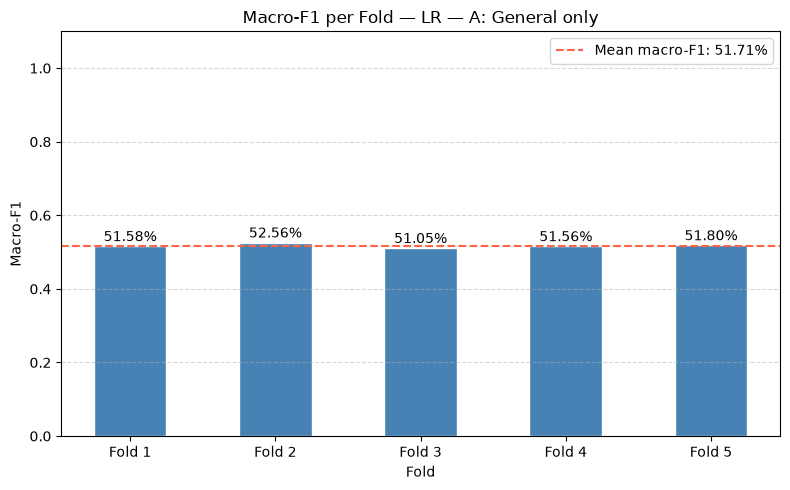

Best hyperparameters: {'class_weight': 'balanced', 'C': 1}
CV macro-F1: 51.71%

LR — A: General only | DOMAIN TEST macro-F1 = 0.1385 | accuracy = 0.1465

              precision    recall  f1-score   support

   ambiguous       0.11      0.23      0.15       174
   amusement       0.13      0.15      0.14       164
       anger       0.06      0.17      0.08        77
     anxiety       0.17      0.01      0.02       273
      belief       0.13      0.16      0.14       181
   confusion       0.19      0.28      0.23       122
  depression       0.08      0.20      0.11        41
     disgust       0.26      0.04      0.07       256
  excitement       0.22      0.16      0.19       277
    optimism       0.21      0.21      0.21       325
       panic       0.17      0.08      0.11        61
    surprise       0.19      0.24      0.21        49

    accuracy                           0.15      2000
   macro avg       0.16      0.16      0.14      2000
weighted avg       0.18      0.15 

In [20]:
# Test - Model A
lr_A, best_lr_A = validate_model_kfold(
    LogisticRegression(random_state=seed, max_iter=1000),
    param_dist_lr, X_A_train, y_A_train, name="LR — A: General only", n_iter=6)

pred_lr_A = evaluate(lr_A, X_domain_test_A, y_domain_test, "LR — A: General only")

Fitting 5 folds for each of 3 candidates, totalling 15 fits


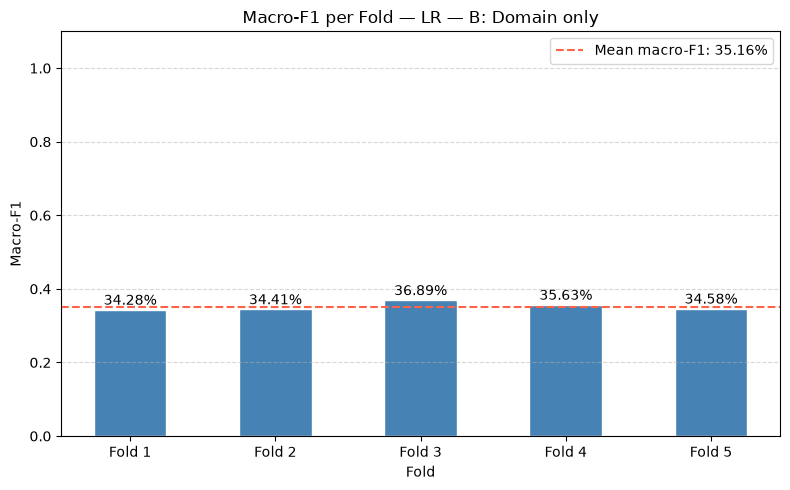

Best hyperparameters: {'class_weight': 'balanced', 'C': 1}
CV macro-F1: 35.16%

LR — B: Domain only | DOMAIN TEST macro-F1 = 0.3671 | accuracy = 0.3795

              precision    recall  f1-score   support

   ambiguous       0.29      0.23      0.25       174
   amusement       0.32      0.46      0.37       164
       anger       0.37      0.52      0.43        77
     anxiety       0.42      0.28      0.34       273
      belief       0.32      0.37      0.34       181
   confusion       0.55      0.55      0.55       122
  depression       0.24      0.32      0.27        41
     disgust       0.44      0.52      0.47       256
  excitement       0.47      0.39      0.43       277
    optimism       0.39      0.31      0.34       325
       panic       0.31      0.43      0.36        61
    surprise       0.21      0.31      0.25        49

    accuracy                           0.38      2000
   macro avg       0.36      0.39      0.37      2000
weighted avg       0.39      0.38  

In [21]:
# Logistic Regression — Model B: Domain only
lr_B, best_lr_B = validate_model_kfold(
    LogisticRegression(
        random_state=seed,
        max_iter=1000
    ),
    param_dist_lr,
    X_B_train,
    y_B_train,
    name="LR — B: Domain only",
    n_iter=3
)

pred_lr_B = evaluate(
    lr_B,
    X_domain_test_B,
    y_domain_test,
    "LR — B: Domain only"
)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


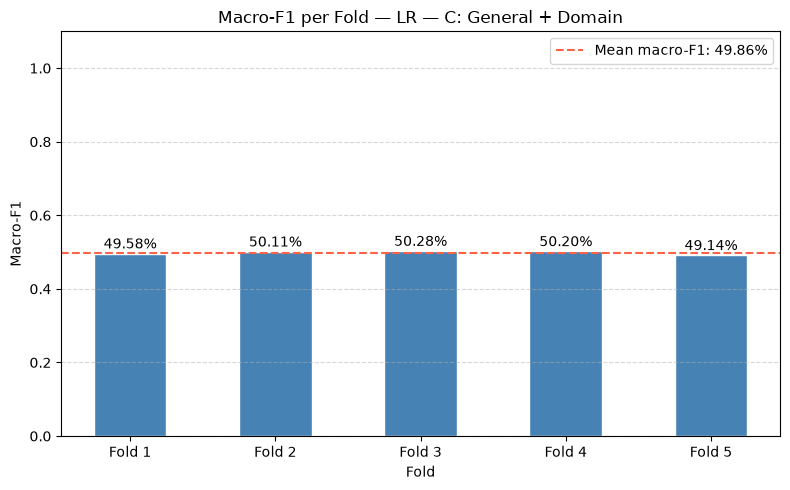

Best hyperparameters: {'class_weight': 'balanced', 'C': 1}
CV macro-F1: 49.86%

LR — C: General + Domain | DOMAIN TEST macro-F1 = 0.2750 | accuracy = 0.3320

              precision    recall  f1-score   support

   ambiguous       0.20      0.21      0.20       174
   amusement       0.21      0.16      0.18       164
       anger       0.50      0.08      0.13        77
     anxiety       0.29      0.57      0.39       273
      belief       0.24      0.02      0.04       181
   confusion       0.61      0.38      0.46       122
  depression       0.27      0.10      0.14        41
     disgust       0.35      0.56      0.43       256
  excitement       0.43      0.41      0.42       277
    optimism       0.36      0.30      0.33       325
       panic       0.30      0.34      0.32        61
    surprise       0.30      0.20      0.24        49

    accuracy                           0.33      2000
   macro avg       0.34      0.28      0.27      2000
weighted avg       0.34      0

In [22]:
# Logistic Regression — Model C: General + Domain
lr_C, best_lr_C = validate_model_kfold(
    LogisticRegression(
        random_state=seed,
        max_iter=1000
    ),
    param_dist_lr,
    X_C_train,
    y_C_train,
    name="LR — C: General + Domain",
    n_iter=3
)

pred_lr_C = evaluate(
    lr_C,
    X_domain_test_C,
    y_domain_test,
    "LR — C: General + Domain"
)

## SVM

Fitting 5 folds for each of 2 candidates, totalling 10 fits


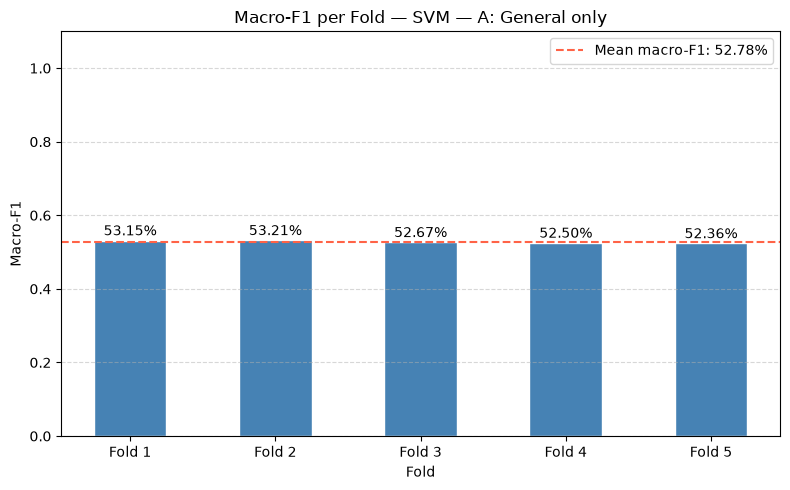

Best hyperparameters: {'class_weight': 'balanced', 'C': 0.1}
CV macro-F1: 52.78%

SVM — A: General only | DOMAIN TEST macro-F1 = 0.1443 | accuracy = 0.1485

              precision    recall  f1-score   support

   ambiguous       0.11      0.16      0.13       174
   amusement       0.13      0.21      0.16       164
       anger       0.06      0.17      0.09        77
     anxiety       0.15      0.02      0.04       273
      belief       0.13      0.24      0.17       181
   confusion       0.21      0.34      0.26       122
  depression       0.08      0.20      0.12        41
     disgust       0.19      0.03      0.05       256
  excitement       0.25      0.14      0.18       277
    optimism       0.20      0.16      0.18       325
       panic       0.16      0.11      0.13        61
    surprise       0.17      0.33      0.22        49

    accuracy                           0.15      2000
   macro avg       0.15      0.18      0.14      2000
weighted avg       0.17      0.

In [23]:
# SVM — Model A: General only
svm_A, best_svm_A = validate_model_kfold(
    LinearSVC(random_state=seed),
    param_dist_svc,
    X_A_train,
    y_A_train,
    name="SVM — A: General only",
    n_iter=2
)

pred_svm_A = evaluate(
    svm_A,
    X_domain_test_A,
    y_domain_test,
    "SVM — A: General only"
)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


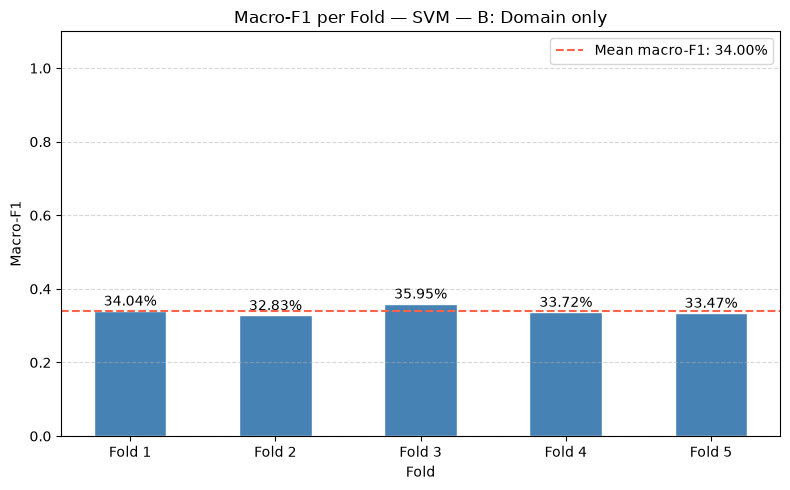

Best hyperparameters: {'class_weight': 'balanced', 'C': 0.1}
CV macro-F1: 34.00%

SVM — B: Domain only | DOMAIN TEST macro-F1 = 0.3646 | accuracy = 0.3840

              precision    recall  f1-score   support

   ambiguous       0.28      0.18      0.22       174
   amusement       0.31      0.45      0.37       164
       anger       0.36      0.55      0.43        77
     anxiety       0.43      0.27      0.33       273
      belief       0.38      0.35      0.36       181
   confusion       0.53      0.59      0.56       122
  depression       0.20      0.32      0.24        41
     disgust       0.43      0.54      0.48       256
  excitement       0.49      0.43      0.46       277
    optimism       0.41      0.30      0.34       325
       panic       0.31      0.48      0.37        61
    surprise       0.16      0.29      0.21        49

    accuracy                           0.38      2000
   macro avg       0.36      0.39      0.36      2000
weighted avg       0.39      0.3

In [24]:
# SVM — Model B: Domain only
svm_B, best_svm_B = validate_model_kfold(
    LinearSVC(random_state=seed),
    param_dist_svc,
    X_B_train,
    y_B_train,
    name="SVM — B: Domain only",
    n_iter=2
)

pred_svm_B = evaluate(
    svm_B,
    X_domain_test_B,
    y_domain_test,
    "SVM — B: Domain only"
)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


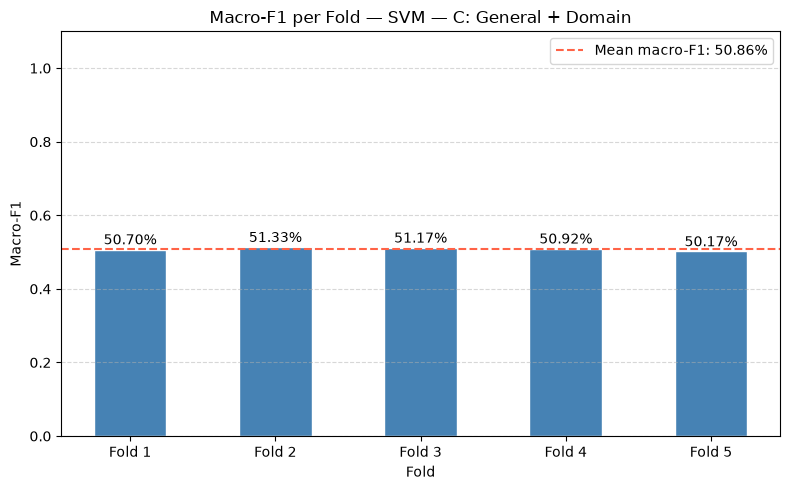

Best hyperparameters: {'class_weight': 'balanced', 'C': 0.1}
CV macro-F1: 50.86%

SVM — C: General + Domain | DOMAIN TEST macro-F1 = 0.2982 | accuracy = 0.3455

              precision    recall  f1-score   support

   ambiguous       0.23      0.16      0.19       174
   amusement       0.20      0.17      0.19       164
       anger       0.67      0.18      0.29        77
     anxiety       0.31      0.60      0.41       273
      belief       0.23      0.05      0.08       181
   confusion       0.61      0.43      0.51       122
  depression       0.23      0.17      0.20        41
     disgust       0.36      0.61      0.45       256
  excitement       0.44      0.41      0.42       277
    optimism       0.37      0.28      0.32       325
       panic       0.28      0.28      0.28        61
    surprise       0.32      0.20      0.25        49

    accuracy                           0.35      2000
   macro avg       0.35      0.30      0.30      2000
weighted avg       0.35    

In [25]:
# SVM — Model C: General + Domain
svm_C, best_svm_C = validate_model_kfold(
    LinearSVC(random_state=seed),
    param_dist_svc,
    X_C_train,
    y_C_train,
    name="SVM — C: General + Domain",
    n_iter=2
)

pred_svm_C = evaluate(
    svm_C,
    X_domain_test_C,
    y_domain_test,
    "SVM — C: General + Domain"
)

## Naive Bayes

Fitting 5 folds for each of 3 candidates, totalling 15 fits


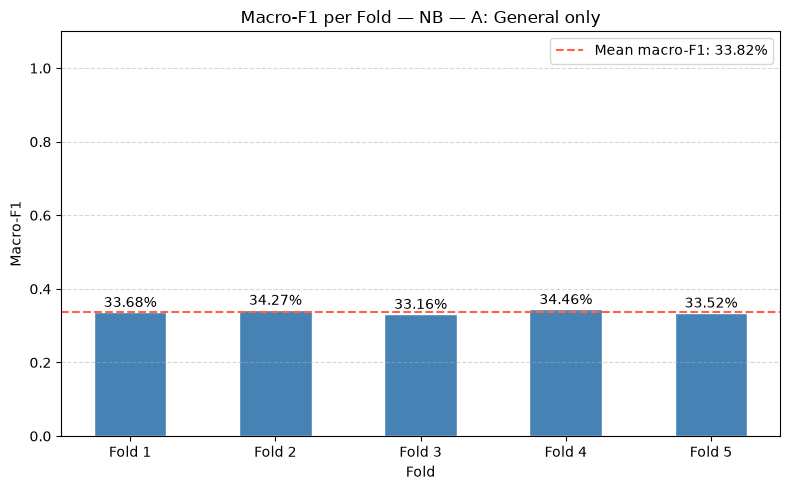

Best hyperparameters: {'alpha': 0.1}
CV macro-F1: 33.82%

NB — A: General only | DOMAIN TEST macro-F1 = 0.0891 | accuracy = 0.1220

              precision    recall  f1-score   support

   ambiguous       0.09      0.01      0.01       174
   amusement       0.15      0.24      0.18       164
       anger       0.09      0.26      0.14        77
     anxiety       0.00      0.00      0.00       273
      belief       0.10      0.71      0.18       181
   confusion       0.24      0.15      0.18       122
  depression       0.13      0.17      0.15        41
     disgust       0.00      0.00      0.00       256
  excitement       0.28      0.06      0.10       277
    optimism       0.19      0.04      0.07       325
       panic       1.00      0.02      0.03        61
    surprise       0.12      0.02      0.04        49

    accuracy                           0.12      2000
   macro avg       0.20      0.14      0.09      2000
weighted avg       0.15      0.12      0.08      2000



In [26]:
# Naive Bayes — Model A: General only
nb_A, best_nb_A = validate_model_kfold(
    MultinomialNB(),
    param_dist_nb,
    X_A_train,
    y_A_train,
    name="NB — A: General only",
    n_iter=3
)

pred_nb_A = evaluate(
    nb_A,
    X_domain_test_A,
    y_domain_test,
    "NB — A: General only"
)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


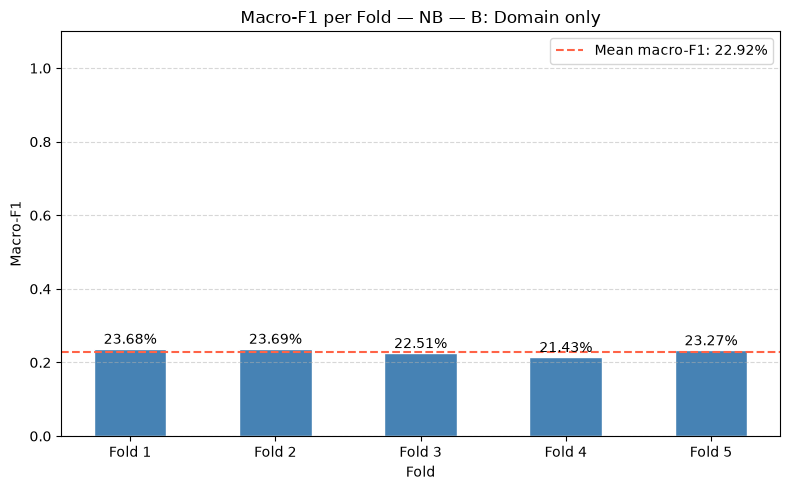

Best hyperparameters: {'alpha': 0.1}
CV macro-F1: 22.92%

NB — B: Domain only | DOMAIN TEST macro-F1 = 0.2437 | accuracy = 0.3280

              precision    recall  f1-score   support

   ambiguous       0.24      0.14      0.17       174
   amusement       0.37      0.23      0.28       164
       anger       0.77      0.13      0.22        77
     anxiety       0.34      0.41      0.37       273
      belief       0.29      0.13      0.18       181
   confusion       0.51      0.16      0.24       122
  depression       0.50      0.02      0.05        41
     disgust       0.34      0.59      0.43       256
  excitement       0.34      0.42      0.37       277
    optimism       0.29      0.47      0.36       325
       panic       0.67      0.10      0.17        61
    surprise       1.00      0.04      0.08        49

    accuracy                           0.33      2000
   macro avg       0.47      0.24      0.24      2000
weighted avg       0.38      0.33      0.30      2000



In [27]:
# Naive Bayes — Model B: Domain only
nb_B, best_nb_B = validate_model_kfold(
    MultinomialNB(),
    param_dist_nb,
    X_B_train,
    y_B_train,
    name="NB — B: Domain only",
    n_iter=3
)

pred_nb_B = evaluate(
    nb_B,
    X_domain_test_B,
    y_domain_test,
    "NB — B: Domain only"
)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


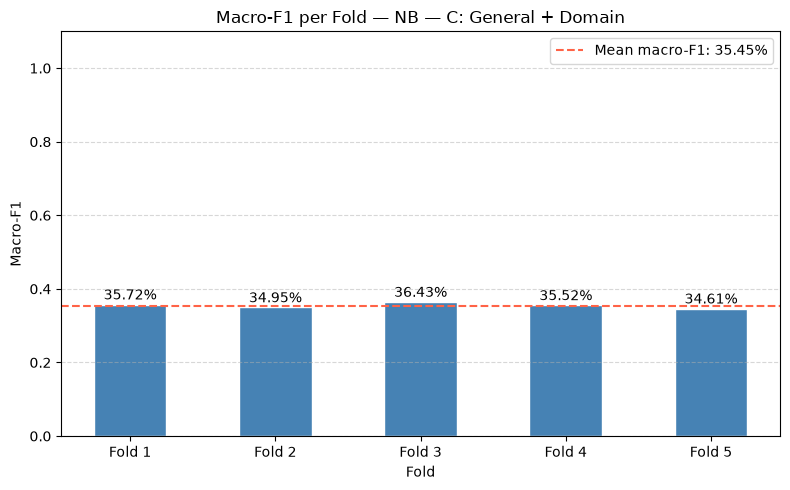

Best hyperparameters: {'alpha': 0.1}
CV macro-F1: 35.45%

NB — C: General + Domain | DOMAIN TEST macro-F1 = 0.2313 | accuracy = 0.3070

              precision    recall  f1-score   support

   ambiguous       0.20      0.11      0.15       174
   amusement       0.28      0.13      0.18       164
       anger       0.50      0.16      0.24        77
     anxiety       0.32      0.44      0.37       273
      belief       0.20      0.09      0.13       181
   confusion       0.52      0.25      0.33       122
  depression       0.10      0.02      0.04        41
     disgust       0.34      0.51      0.40       256
  excitement       0.31      0.40      0.35       277
    optimism       0.28      0.45      0.34       325
       panic       0.60      0.10      0.17        61
    surprise       0.50      0.04      0.08        49

    accuracy                           0.31      2000
   macro avg       0.34      0.22      0.23      2000
weighted avg       0.32      0.31      0.28      200

In [28]:
# Naive Bayes — Model C: General + Domain
nb_C, best_nb_C = validate_model_kfold(
    MultinomialNB(),
    param_dist_nb,
    X_C_train,
    y_C_train,
    name="NB — C: General + Domain",
    n_iter=3
)

pred_nb_C = evaluate(
    nb_C,
    X_domain_test_C,
    y_domain_test,
    "NB — C: General + Domain"
)

In [29]:
def create_result(algorithm, strategy, predictions):
    return {
        "Algorithm": algorithm,
        "Strategy": strategy,
        "Accuracy": (
            predictions == y_domain_test
        ).mean(),
        "Macro F1": f1_score(
            y_domain_test,
            predictions,
            average="macro",
            zero_division=0
        )
    }


results = pd.DataFrame([
    # Logistic Regression
    create_result(
        "Logistic Regression",
        "A: General only",
        pred_lr_A
    ),
    create_result(
        "Logistic Regression",
        "B: Domain only",
        pred_lr_B
    ),
    create_result(
        "Logistic Regression",
        "C: General + Domain",
        pred_lr_C
    ),

    # SVM
    create_result("SVM", "A: General only", pred_svm_A),
    create_result("SVM", "B: Domain only", pred_svm_B),
    create_result("SVM", "C: General + Domain", pred_svm_C),

    # Naive Bayes
    create_result("Naive Bayes", "A: General only", pred_nb_A),
    create_result("Naive Bayes", "B: Domain only", pred_nb_B),
    create_result("Naive Bayes", "C: General + Domain", pred_nb_C)
])

results = results.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

display(results)

,Algorithm,Strategy,Accuracy,Macro F1
0,Logistic Regression,B: Domain only,0.3795,0.367062
1,SVM,B: Domain only,0.3840,0.364638
2,SVM,C: General + Domain,0.3455,0.298245
3,Logistic Regression,C: General + Domain,0.3320,0.274970
4,Naive Bayes,B: Domain only,0.3280,0.243660
5,Naive Bayes,C: General + Domain,0.3070,0.231318
6,SVM,A: General only,0.1485,0.144307
7,Logistic Regression,A: General only,0.1465,0.138451
8,Naive Bayes,A: General only,0.1220,0.089055


1. Domain-only training performs best

Financial training data is much more useful for predicting financial emotions than general opinion data.

2. General-only models perform poorly

These low scores demonstrate a strong domain shift. General emotional language does not transfer reliably to specialised financial language.

3. Mixed training does not improve performance

This suggests negative transfer: adding general data introduces language patterns that do not match the financial domain. The general dataset is also much larger, so it may dominate Model C’s learning.

4. Logistic Regression and SVM are very close

The difference is only approximately 0.0024, so you should not claim Logistic Regression is significantly better without repeated experiments. You can say their performance is comparable.

Domain-only training produced the strongest traditional machine-learning baseline. Logistic Regression achieved the highest macro F1 of 0.3671, closely followed by SVM at 0.3646. General-only models performed poorly on the financial test set, demonstrating a substantial cross-domain performance gap. Mixed training also underperformed domain-only training, suggesting that combining a much larger general dataset with specialised financial data introduced negative transfer rather than improving generalisation.

In [31]:
test_sentence = [
    "Tesla reported stronger-than-expected earnings, and investors are optimistic that the share price will continue to rise."
]

prediction = lr_B.predict(
    vec_B.transform(test_sentence)
)

print("Predicted emotion:", prediction[0])

Predicted emotion: belief


In [32]:
test_sentence = [
    "Tesla reported stronger-than-expected earnings, and investors are optimistic that the share price will continue to rise."
]

X_new = vec_B.transform(test_sentence)

probabilities = lr_B.predict_proba(X_new)[0]
top_indices = probabilities.argsort()[::-1][:3]

print("Top predictions:")

for index in top_indices:
    print(
        lr_B.classes_[index],
        f"{probabilities[index]:.2%}"
    )

Top predictions:
belief 19.47%
anxiety 13.31%
optimism 9.93%
